#Trabalho AP1 — Modelagem Preditiva de Saúde Mental
## Machine Learning | IBMEC | 2026-1

| Item | Detalhe |
|---|---|
| **Dataset** | ICCMH 2020 — Statistics Canada (45.989 registros, 43 colunas) |
| **Variável-alvo** | `ANXDVGAC` — Transtorno de Ansiedade Generalizada (GAD-7) |
| **Referência metodológica** | Lones (2024). *Avoiding common machine learning pitfalls.* Patterns, 5(10). |

---


---
## Seção 1 — Setup e Dependências
> Fixamos a seed global para garantir **reprodutibilidade total** do experimento (Lones, 2024).


In [ ]:
!pip install statsmodels --quiet

import random, numpy as np, os, sys, warnings
warnings.filterwarnings('ignore')

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, brier_score_loss,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    make_scorer
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from scipy.stats import loguniform, randint

# ── Estilo global dos gráficos ─────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 11,
})

# ── Paleta de cores padrão do projeto ─────────────────────────
COR_POSITIVO = '#E24B4A'
COR_NEGATIVO = '#378ADD'
COR_BASELINE = '#888780'
COR_GB       = '#1D9E75'

print(f"Seed global: {GLOBAL_SEED}")
print(f"Imports concluídos — Python {sys.version.split()[0]}")


Seed global: 42
Imports concluídos — Python 3.12.13


---
## Seção 2 — Carregamento dos Dados e Dicionário de Variáveis


In [ ]:
URL = 'https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/iccmh2020rccsm_p.csv'
df = pd.read_csv(URL)

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
df.head(3)


Dataset carregado: 45,989 linhas × 43 colunas


,PUMFID,VERDATE,MH_05,MH_10,MH_15A,MH_15B,MH_15C,MH_15D,MH_15E,MH_15F,...,PCSIZMIZ,PIIDFLAG,PIMMST,PLM_30,PLM_40,PPROV,PRURURB,PVISMIN,PAGEGR,PUMFFACT
0,5106,10/06/2020,3,3,3,4,2,2,2,2,...,2,2,1,5,4,35,2,1,6,0.4165
1,5107,10/06/2020,3,3,3,1,2,2,1,2,...,3,2,1,4,4,13,2,2,7,0.7167
2,5108,10/06/2020,1,3,1,1,1,1,1,1,...,3,2,1,5,4,12,2,2,4,0.5585


In [ ]:
dicionario = {
    'ANXDVGAC' : ' TARGET — TAG presente (1) ou ausente (2) — derivado do GAD-7',
    'ANXDVGAD' : ' Score bruto GAD-7 (0–21) — PROIBIDA: causa leakage',
    'ANXDVSEV' : 'Severidade do GAD-7 — PROIBIDA: causa leakage',
    'MH_05'    : 'Saúde mental auto-avaliada (1=Excelente … 5=Ruim)',
    'MH_15A–G' : 'Itens individuais do GAD-7 — PROIBIDAS: causam leakage',
    'DEM_10'   : 'Gênero (1=Masculino, 2=Feminino)',
    'AGEGR_10' : 'Faixa etária (1=15-24 … 6=65+)',
    'PIMMST'   : 'Status de imigração (1=Imigrante, 2=Não imigrante)',
    'PRURURB'  : 'Área de residência (1=Urbano, 2=Rural)',
    'MHDVMHI'  : 'Índice de saúde mental (1=Alto, 2=Moderado, 3=Baixo)',
    'PUMFID'   : 'ID do respondente — ADMINISTRATIVA',
    'VERDATE'  : 'Versão do arquivo — ADMINISTRATIVA',
}
pd.DataFrame.from_dict(dicionario, orient='index', columns=['Descrição'])


,Descrição
ANXDVGAC,TARGET — TAG presente (1) ou ausente (2) — de...
ANXDVGAD,Score bruto GAD-7 (0–21) — PROIBIDA: causa le...
ANXDVSEV,Severidade do GAD-7 — PROIBIDA: causa leakage
MH_05,Saúde mental auto-avaliada (1=Excelente … 5=Ruim)
MH_15A–G,Itens individuais do GAD-7 — PROIBIDAS: causam...
DEM_10,"Gênero (1=Masculino, 2=Feminino)"
AGEGR_10,Faixa etária (1=15-24 … 6=65+)
PIMMST,"Status de imigração (1=Imigrante, 2=Não imigra..."
PRURURB,"Área de residência (1=Urbano, 2=Rural)"
MHDVMHI,"Índice de saúde mental (1=Alto, 2=Moderado, 3=..."


---
##Seção 3 — Seleção da Variável-Alvo

### Tabela de avaliação pelos 4 critérios obrigatórios

| Variável | ✅ Instrumento validado | ✅ Sem leakage | ✅ Qualidade dos dados | ✅ Política pública |
|---|---|---|---|---|
| `ANXDVGAD` | ✅ GAD-7 (Spitzer et al., 2006) | ✅ Sem leakage externo | ❌ **26% missing** | ✅ Triagem |
| **`ANXDVGAC`** | ✅ GAD-7 (Spitzer et al., 2006) | ✅ Sem leakage externo | ✅ **1,4% missing** | ✅ Triagem |
| `ANXDVSEV` | ✅ GAD-7 | ❌ **r=0,87 com alvo** | ✅ 1,4% missing | ✅ Triagem |
| `MH_05` | ❌ Pergunta única (sem validação) | ✅ Sem leakage | ✅ 0% missing | ⚠️ Pouco acionável |

**Escolha: `ANXDVGAC`** — único candidato que passa nos 4 critérios simultaneamente.
andar + andar =0.1 andar + esperar=0.2 andar+pular = 0.7 pular + andar= 0.8 pular+ esperar=0.1 pular+pular=0.1 esperar + esperar = 0.5 esperar+pular=0.1 esperar + andar=0.4


In [ ]:
# ── 3.1 Diagnóstico das candidatas ────────────────────────────
missing_config = {'ANXDVGAD':[99], 'ANXDVGAC':[9], 'ANXDVSEV':[9], 'MH_05':[9]}

print("MISSING REAL POR CANDIDATA")
print("="*50)
for col, codigos in missing_config.items():
    n_nan = df[col].isna().sum()
    n_esp = df[col].isin(codigos).sum()
    pct   = (n_nan + n_esp) / len(df) * 100
    print(f" {pct:.1f}% missing")

# ── 3.2 Análise de leakage ─────────────────────────────────────
print("\nANÁLISE DE LEAKAGE")
print("="*50)

sub = df[['ANXDVGAC','ANXDVGAD']].replace({99:np.nan, 9:np.nan}).dropna()
erros = (len(sub[(sub['ANXDVGAC']==1) & (sub['ANXDVGAD']<10)]) +
         len(sub[(sub['ANXDVGAC']==2) & (sub['ANXDVGAD']>=10)]))
print(f"  ANXDVGAD → ANXDVGAC: {erros} discrepâncias {' sem leakage' if erros>0 else ' LEAKAGE DETERMINÍSTICO'}")

sub2 = df[['ANXDVSEV','ANXDVGAC']].replace(9, np.nan).dropna()
r_sv, _ = pearsonr(sub2['ANXDVSEV'], sub2['ANXDVGAC'])
print(f"  ANXDVSEV × ANXDVGAC: r = {r_sv:.3f} {' LEAKAGE (r > 0.7)' if abs(r_sv)>0.7 else ' ok'}")

df_check = df.copy()
df_check['TARGET'] = df_check['ANXDVGAC'].map({1:1, 2:0})
mh15_cols = [c for c in df.columns if c.startswith('MH_15')]
rs = []
for col in mh15_cols:
    sub3 = df_check[[col,'TARGET']].dropna()
    r, _ = pearsonr(sub3[col], sub3['TARGET'])
    rs.append(abs(r))
if rs:
    print(f"  MH_15A–G × TARGET: r médio = {np.mean(rs):.3f} LEAKAGE (itens do GAD-7)")

# ── 3.3 Preparar variável-alvo ────────────────────────────────
df['ANXDVGAC'] = df['ANXDVGAC'].replace(9, np.nan)
df['TARGET']   = df['ANXDVGAC'].map({1:1, 2:0})
dist = df['TARGET'].value_counts()
print(f"\nVARIÁVEL-ALVO FINAL (TARGET)")
print(f"  Com TAG (1): {dist.get(1,0):,} ({dist.get(1,0)/dist.sum()*100:.1f}%)")
print(f"  Sem TAG (0): {dist.get(0,0):,} ({dist.get(0,0)/dist.sum()*100:.1f}%)")
print(f"  Razão: {dist.max()/dist.min():.1f}:1  abaixo do limite de 10:1")


MISSING REAL POR CANDIDATA
 1.4% missing
 1.4% missing
 1.4% missing
 0.0% missing

ANÁLISE DE LEAKAGE
  ANXDVGAD → ANXDVGAC: 0 discrepâncias  LEAKAGE DETERMINÍSTICO
  ANXDVSEV × ANXDVGAC: r = -0.829  LEAKAGE (r > 0.7)
  MH_15A–G × TARGET: r médio = 0.681 LEAKAGE (itens do GAD-7)

VARIÁVEL-ALVO FINAL (TARGET)
  Com TAG (1): 13,199 (29.1%)
  Sem TAG (0): 32,167 (70.9%)
  Razão: 2.4:1  abaixo do limite de 10:1


---
## Seção 4 — Limpeza dos Dados e Análise de Missing


Shape após remover proibidas: (45366, 32)
   Distribuição do alvo: {0: 32167, 1: 13199}


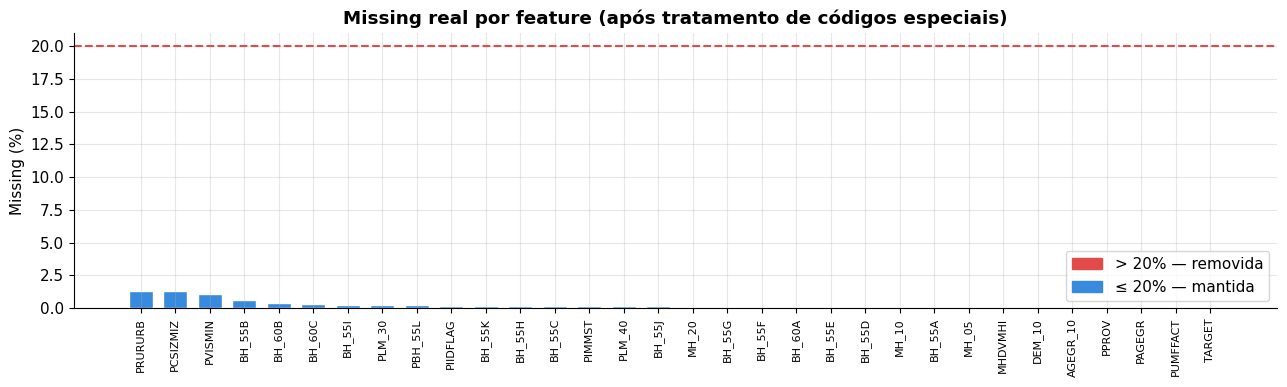

 Nenhuma feature removida por missing.
 Shape final: (45366, 32)


In [ ]:
FEATURES_PROIBIDAS = [
    'ANXDVGAD', 'ANXDVSEV',
    'MH_15A','MH_15B','MH_15C','MH_15D','MH_15E','MH_15F','MH_15G',
    'PUMFID', 'VERDATE', 'ANXDVGAC',
]

df_model = df.drop(columns=FEATURES_PROIBIDAS, errors='ignore').copy()
df_model = df_model[df['TARGET'].notna()].copy()
y = df.loc[df['TARGET'].notna(), 'TARGET'].astype(int)

print(f"Shape após remover proibidas: {df_model.shape}")
print(f"   Distribuição do alvo: {y.value_counts().to_dict()}")

# ── Tratar códigos especiais de missing ────────────────────────
def tratar_codigos_especiais(df_input):
    df_out = df_input.copy()
    for col in df_out.columns:
        vals = df_out[col].dropna()
        if len(vals) == 0: continue
        codigos = [9] if vals.max() <= 9 else [96,97,98,99] if vals.max() <= 99 else []
        df_out[col] = df_out[col].replace(codigos, np.nan)
    return df_out

df_model = tratar_codigos_especiais(df_model)

# ── Gráfico de missing ─────────────────────────────────────────
missing_real = (df_model.isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
cores = [COR_POSITIVO if v > 20 else COR_NEGATIVO for v in missing_real.values]
ax.bar(missing_real.index, missing_real.values, color=cores, width=0.7, edgecolor='white')
ax.axhline(20, color=COR_POSITIVO, linestyle='--', lw=1.5, label='Limite 20%')
ax.set_title('Missing real por feature (após tratamento de códigos especiais)', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xticks(range(len(missing_real)))
ax.set_xticklabels(missing_real.index, rotation=90, fontsize=8)
legenda = [mpatches.Patch(color=COR_POSITIVO, label='> 20% — removida'),
           mpatches.Patch(color=COR_NEGATIVO, label='≤ 20% — mantida')]
ax.legend(handles=legenda)
plt.tight_layout(); plt.show()

# ── Remover features com missing > 20% ───────────────────────
colunas_remover = missing_real[missing_real > 20].index.tolist()
if colunas_remover:
    df_model = df_model.drop(columns=colunas_remover)
    print(f"  Removidas por missing > 20%: {colunas_remover}")
else:
    print(" Nenhuma feature removida por missing.")
print(f" Shape final: {df_model.shape}")


---
## Seção 5 — Análise Exploratória de Dados (EDA)


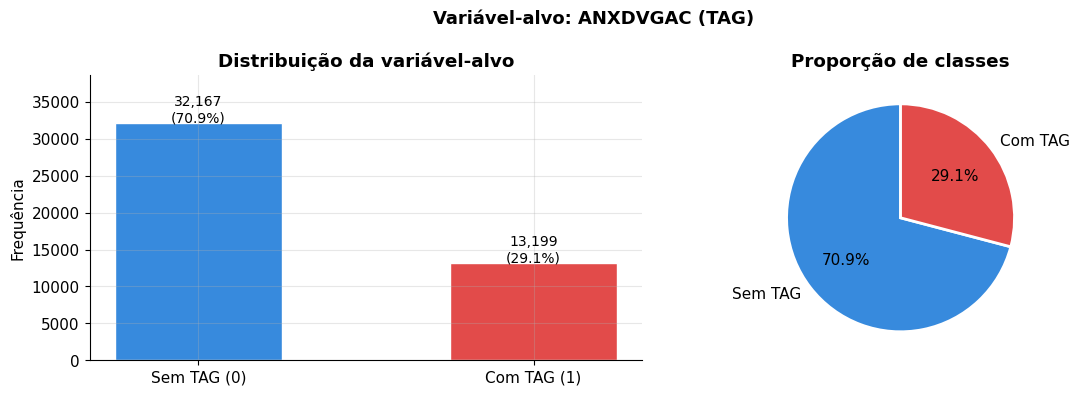

Razão de desbalanceamento: 2.4:1


In [ ]:
LABELS = {
    'DEM_10'   : {1:'Masculino', 2:'Feminino'},
    'AGEGR_10' : {1:'15-24', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65+'},
    'PIMMST'   : {1:'Imigrante', 2:'Não imigrante'},
    'MH_05'    : {1:'Excelente', 2:'Muito boa', 3:'Boa', 4:'Razoável', 5:'Ruim'},
    'MHDVMHI'  : {1:'Alto', 2:'Moderado', 3:'Baixo'},
}

df_eda = df_model.copy()
df_eda['TARGET'] = y.values

# ── 5.1 Distribuição da variável-alvo ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagens = df_eda['TARGET'].value_counts().sort_index()
bars = axes[0].bar(['Sem TAG (0)', 'Com TAG (1)'], contagens.values,
                    color=[COR_NEGATIVO, COR_POSITIVO], width=0.5, edgecolor='white')
for bar, v in zip(bars, contagens.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
                 f'{v:,}\n({v/len(df_eda)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Distribuição da variável-alvo', fontweight='bold')
axes[0].set_ylabel('Frequência')
axes[0].set_ylim(0, contagens.max()*1.2)

axes[1].pie(contagens.values, labels=['Sem TAG', 'Com TAG'],
            colors=[COR_NEGATIVO, COR_POSITIVO],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporção de classes', fontweight='bold')

plt.suptitle('Variável-alvo: ANXDVGAC (TAG)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Razão de desbalanceamento: {contagens.max()/contagens.min():.1f}:1")


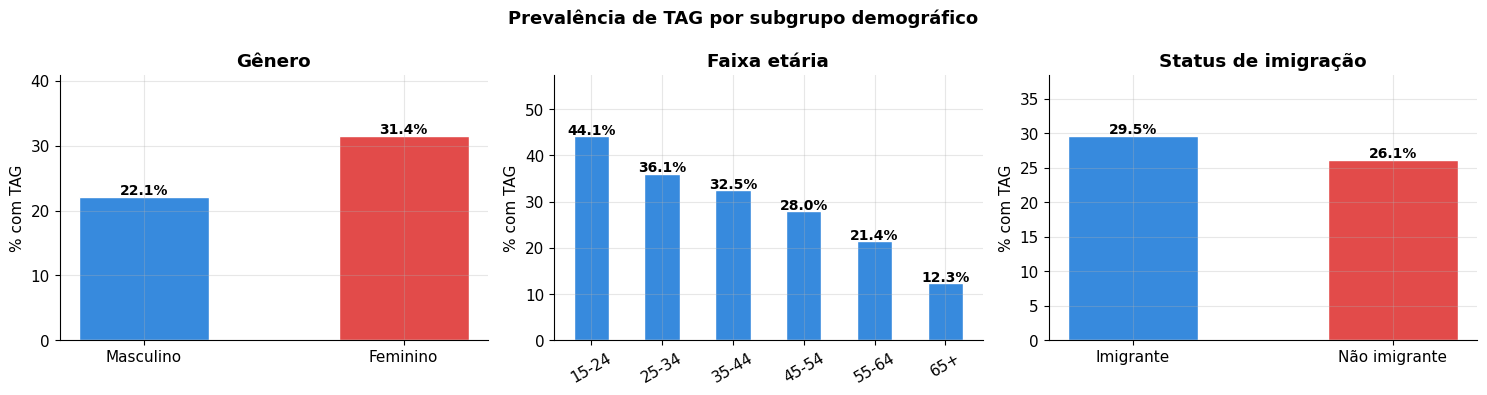

In [ ]:
# ── 5.2 Prevalência por subgrupos demográficos ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Prevalência de TAG por subgrupo demográfico', fontsize=13, fontweight='bold')

configs = [
    ('DEM_10',   'Gênero',             [COR_NEGATIVO, COR_POSITIVO]),
    ('AGEGR_10', 'Faixa etária',       [COR_NEGATIVO]*6),
    ('PIMMST',   'Status de imigração',[COR_NEGATIVO, COR_POSITIVO]),
]

for ax, (var, titulo, cores) in zip(axes, configs):
    sub = df_eda.dropna(subset=[var])
    grupos = sub.groupby(var)['TARGET'].mean() * 100
    rotulos = [LABELS[var].get(k, str(k)) for k in grupos.index]
    bars = ax.bar(rotulos, grupos.values, color=cores, width=0.5, edgecolor='white')
    for bar, v in zip(bars, grupos.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% com TAG')
    ax.set_ylim(0, grupos.max()*1.3)
    if var == 'AGEGR_10': ax.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


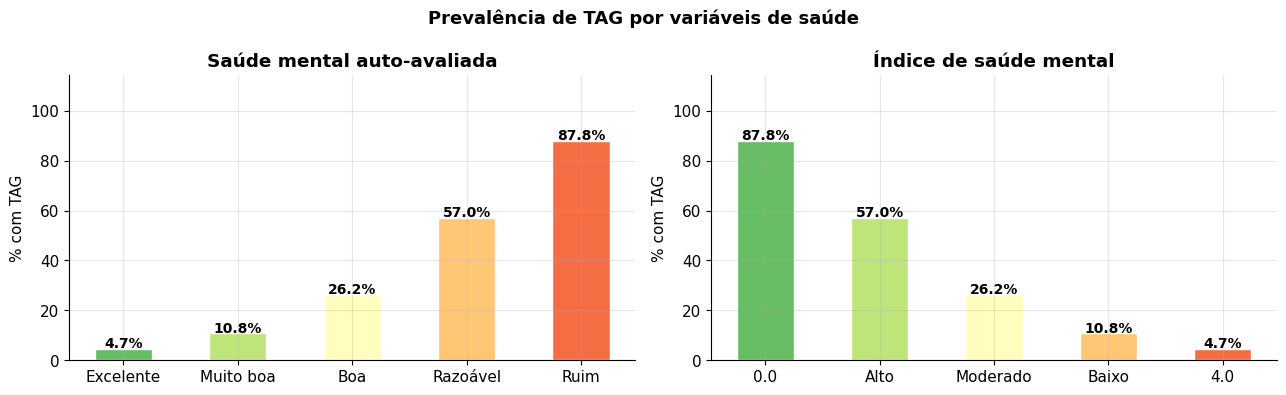

RESUMO DO EDA
  Registros analisados : 45,366
  Prevalência geral TAG: 29.1%
  Gênero: 22.1% – 31.4%
  Faixa etária: 12.3% – 44.1%
  Imigração: 26.1% – 29.5%
  Índice saúde: 4.7% – 87.8%


In [ ]:
# ── 5.3 Prevalência por variáveis de saúde ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Prevalência de TAG por variáveis de saúde', fontsize=13, fontweight='bold')

for ax, (var, titulo) in zip(axes, [('MH_05','Saúde mental auto-avaliada'),
                                      ('MHDVMHI','Índice de saúde mental')]):
    sub = df_eda.dropna(subset=[var])
    grupos = sub.groupby(var)['TARGET'].mean() * 100
    rotulos = [LABELS[var].get(k, str(k)) for k in grupos.index]
    cores_grad = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grupos)))
    bars = ax.bar(rotulos, grupos.values, color=cores_grad, width=0.5, edgecolor='white')
    for bar, v in zip(bars, grupos.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% com TAG')
    ax.set_ylim(0, grupos.max()*1.3)

plt.tight_layout(); plt.show()

print("RESUMO DO EDA")
print("="*45)
print(f"  Registros analisados : {len(df_eda):,}")
print(f"  Prevalência geral TAG: {df_eda['TARGET'].mean()*100:.1f}%")
for var, label in [('DEM_10','Gênero'),('AGEGR_10','Faixa etária'),
                   ('PIMMST','Imigração'),('MHDVMHI','Índice saúde')]:
    sub = df_eda.dropna(subset=[var])
    g = sub.groupby(var)['TARGET'].mean()*100
    print(f"  {label}: {g.min():.1f}% – {g.max():.1f}%")


---
## Seção 6 — Feature Engineering e Feature Selection

> A seleção de features é feita **dentro do Pipeline** via `SelectKBest` —
> garantindo ausência de leakage na validação cruzada (Lones, 2024).
> Esta seção apresenta a análise exploratória dos scores apenas para documentação.


 BH55_SOMA criada a partir de 11 colunas
 N_FEATURES para SelectKBest: 16 de 32 disponíveis


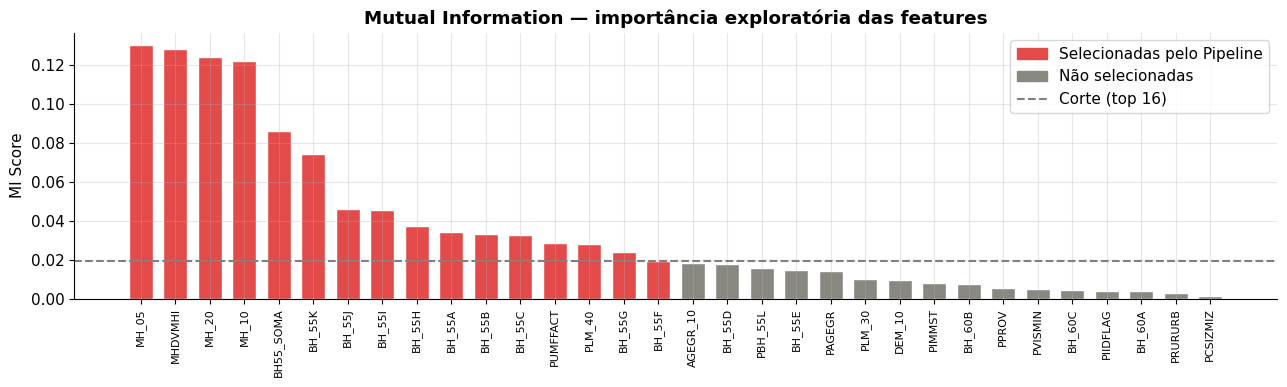


Top 10 features por MI:
MH_05        0.1300
MHDVMHI      0.1281
MH_20        0.1240
MH_10        0.1220
BH55_SOMA    0.0862
BH_55K       0.0745
BH_55J       0.0461
BH_55I       0.0455
BH_55H       0.0374
BH_55A       0.0339


In [ ]:
# ── Feature Engineering ───────────────────────────────────────
bh55_cols = [c for c in df_model.columns if c.startswith('BH_55')]
if bh55_cols:
    df_model['BH55_SOMA'] = df_model[bh55_cols].sum(axis=1)
    print(f" BH55_SOMA criada a partir de {len(bh55_cols)} colunas")

# ── MI exploratório (documentação) ────────────────────────────
X_temp = df_model.copy()
for col in X_temp.columns:
    X_temp[col] = X_temp[col].fillna(X_temp[col].median())

mi_scores = mutual_info_classif(X_temp, y, random_state=42)
mi_series  = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

N_FEATURES = max(5, int(len(mi_series) / 2))
print(f" N_FEATURES para SelectKBest: {N_FEATURES} de {len(mi_series)} disponíveis")

fig, ax = plt.subplots(figsize=(13, 4))
cores_mi = [COR_POSITIVO if v >= mi_series.iloc[N_FEATURES-1]
            else COR_BASELINE for v in mi_series.values]
ax.bar(mi_series.index, mi_series.values, color=cores_mi, width=0.7, edgecolor='white')
ax.axhline(mi_series.iloc[N_FEATURES-1], color='gray', linestyle='--',
           lw=1.5, label=f'Corte (top {N_FEATURES})')
ax.set_title('Mutual Information — importância exploratória das features', fontweight='bold')
ax.set_ylabel('MI Score')
ax.set_xticks(range(len(mi_series)))
ax.set_xticklabels(mi_series.index, rotation=90, fontsize=8)
legenda = [mpatches.Patch(color=COR_POSITIVO, label='Selecionadas pelo Pipeline'),
           mpatches.Patch(color=COR_BASELINE,  label='Não selecionadas')]
ax.legend(handles=legenda + [ax.lines[-1]])
plt.tight_layout(); plt.show()

print("\nTop 10 features por MI:")
print(mi_series.head(10).round(4).to_string())


---
## Seção 7 — Definição dos Pipelines

> Todo o pré-processamento (imputer → scaler → selector → modelo) é encapsulado
> em `sklearn.Pipeline`. O `SelectKBest` **dentro** do pipeline garante que a
> seleção de features use apenas dados de treino de cada fold (Lones, 2024).


In [ ]:
# ── Divisão treino/teste ÚNICA E DEFINITIVA ───────────────────
X = df_model.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("DIVISÃO TREINO / TESTE")
print("="*40)
print(f"  Treino : {X_train.shape[0]:,} registros (80%)")
print(f"  Teste  : {X_test.shape[0]:,} registros (20%)")
print(f"  TAG treino : {y_train.mean():.3f}")
print(f"  TAG teste  : {y_test.mean():.3f}   estratificação correta")
print(f"  Features   : {X_train.shape[1]}")

# ── Definição dos Pipelines ───────────────────────────────────
pipelines = {

    'Dummy_stratified': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     DummyClassifier(strategy='stratified', random_state=42))
    ]),

    'Dummy_majority': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     DummyClassifier(strategy='most_frequent'))
    ]),

    'LogisticRegression': Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
        ('clf',      LogisticRegression(class_weight='balanced',
                                         max_iter=2000, random_state=42))
    ]),

    'RandomForest': Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
        ('clf',      RandomForestClassifier(class_weight='balanced',
                                              n_estimators=100,
                                              random_state=42, n_jobs=-1))
    ]),

    'GradientBoosting': Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
        ('clf',      GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print("\nPipelines definidos:")
for nome, pipe in pipelines.items():
    passos = ' → '.join([p[0] for p in pipe.steps])
    print(f"  {nome}: {passos}")


DIVISÃO TREINO / TESTE
  Treino : 36,292 registros (80%)
  Teste  : 9,074 registros (20%)
  TAG treino : 0.291
  TAG teste  : 0.291   estratificação correta
  Features   : 33

Pipelines definidos:
  Dummy_stratified: imputer → clf
  Dummy_majority: imputer → clf
  LogisticRegression: imputer → scaler → selector → clf
  RandomForest: imputer → selector → clf
  GradientBoosting: imputer → selector → clf


---
## Seção 8 — Validação Cruzada com Múltiplas Seeds

> **StratifiedKFold(5 folds) × 3 seeds = 15 avaliações por modelo.**
> Resultados reportados como média ± desvio padrão (Lones, 2024).
> Métricas: AUC-ROC, Acurácia, F1, Precisão e Recall.


In [ ]:
# Célula do split — substitua o início por:
colunas_remover_x = [c for c in df_model.columns if c in ['TARGET', 'ANXDVGAC']]
if colunas_remover_x:
    print(f"  Removendo do X: {colunas_remover_x}")
    df_model = df_model.drop(columns=colunas_remover_x)

X = df_model.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

  Removendo do X: ['TARGET']


In [ ]:
SEEDS   = [42, 123, 7]
N_FOLDS = 5

# FIX: precision/recall com zero_division para evitar warnings em folds sem positivos
metricas_cv = {
    'roc_auc'  : 'roc_auc',
    'accuracy' : 'accuracy',
    'f1'       : make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall'   : make_scorer(recall_score, zero_division=0),
}

resultados = {}
print("Rodando validação cruzada...")
print(f"{'Modelo':<25} | {'AUC':>6} | {'Acc':>6} | {'F1':>6} | {'Prec':>6} | {'Rec':>6}")
print("-"*65)

for nome, pipe in pipelines.items():
    aucs, accs, f1s, precs, recs = [], [], [], [], []
    for seed in SEEDS:
        cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
        scores = cross_validate(pipe, X_train, y_train,
                                cv=cv, scoring=metricas_cv, n_jobs=-1)
        aucs.extend(scores['test_roc_auc'].tolist())
        accs.extend(scores['test_accuracy'].tolist())
        f1s.extend(scores['test_f1'].tolist())
        precs.extend(scores['test_precision'].tolist())
        recs.extend(scores['test_recall'].tolist())

    resultados[nome] = {
        'AUC_mean' : np.mean(aucs),  'AUC_std' : np.std(aucs),
        'Acc_mean' : np.mean(accs),  'Acc_std' : np.std(accs),
        'F1_mean'  : np.mean(f1s),   'F1_std'  : np.std(f1s),
        'Prec_mean': np.mean(precs), 'Prec_std': np.std(precs),
        'Rec_mean' : np.mean(recs),  'Rec_std' : np.std(recs),
    }
    print(f"  {nome:<23} | {np.mean(aucs):.4f} | {np.mean(accs):.4f} | "
          f"{np.mean(f1s):.4f} | {np.mean(precs):.4f} | {np.mean(recs):.4f}")

df_resultados = pd.DataFrame(resultados).T.sort_values('AUC_mean', ascending=False).round(4)


Rodando validação cruzada...
Modelo                    |    AUC |    Acc |     F1 |   Prec |    Rec
-----------------------------------------------------------------
  Dummy_stratified        | 0.5029 | 0.5920 | 0.2923 | 0.2951 | 0.2897
  Dummy_majority          | 0.5000 | 0.7091 | 0.0000 | 0.0000 | 0.0000
  LogisticRegression      | 0.8940 | 0.8033 | 0.7074 | 0.6239 | 0.8168
  RandomForest            | 0.8907 | 0.8282 | 0.6811 | 0.7407 | 0.6307
  GradientBoosting        | 0.9017 | 0.8366 | 0.7005 | 0.7508 | 0.6567



TABELA COMPARATIVA — CV (3 seeds × 5 folds)
                    AUC_mean  AUC_std  Acc_mean  Acc_std  F1_mean  F1_std  Prec_mean  Prec_std  Rec_mean  Rec_std
GradientBoosting      0.9017   0.0047    0.8366   0.0044   0.7005  0.0072     0.7508    0.0125    0.6567   0.0100
LogisticRegression    0.8940   0.0052    0.8033   0.0062   0.7074  0.0077     0.6239    0.0096    0.8168   0.0084
RandomForest          0.8907   0.0048    0.8282   0.0050   0.6811  0.0096     0.7407    0.0131    0.6307   0.0141
Dummy_stratified      0.5029   0.0067    0.5920   0.0056   0.2923  0.0096     0.2951    0.0097    0.2897   0.0095
Dummy_majority        0.5000   0.0000    0.7091   0.0001   0.0000  0.0000     0.0000    0.0000    0.0000   0.0000


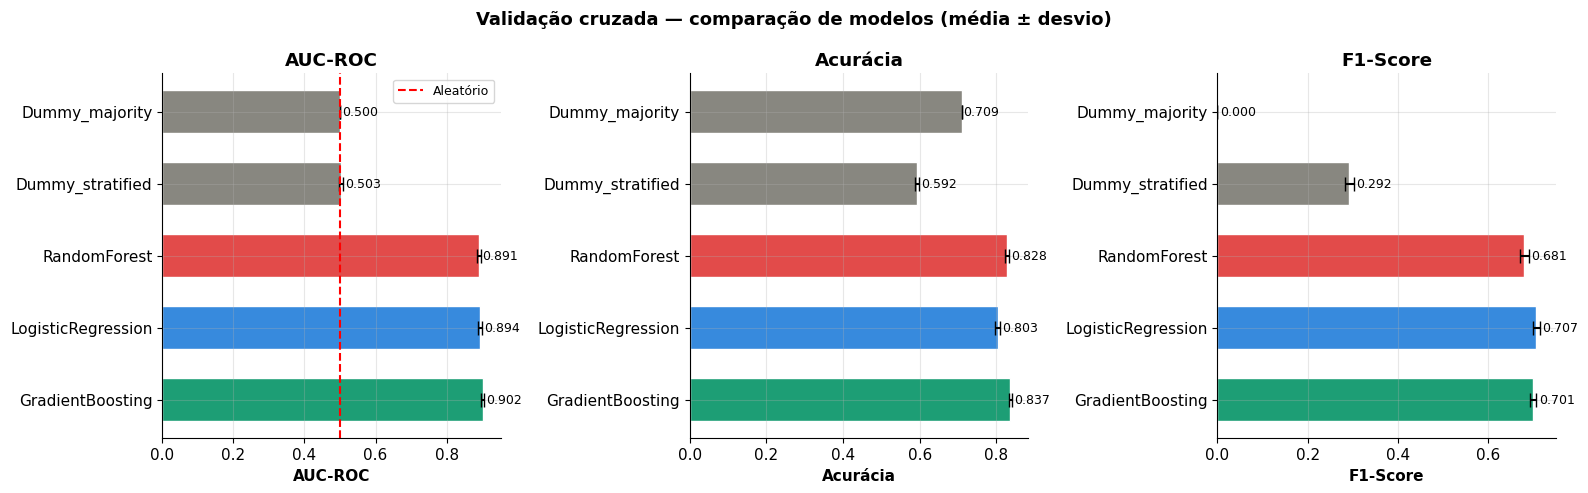


🏆 Melhor na CV: GradientBoosting
   AUC: 0.9017 ± 0.0047

 Conjunto de teste INTOCADO até a Seção 10.


In [ ]:
# ── Tabela resumo ─────────────────────────────────────────────
print("\nTABELA COMPARATIVA — CV (3 seeds × 5 folds)")
print("="*80)
cols_show = ['AUC_mean','AUC_std','Acc_mean','Acc_std',
             'F1_mean','F1_std','Prec_mean','Prec_std','Rec_mean','Rec_std']
print(df_resultados[cols_show].to_string())

# ── Gráfico ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Validação cruzada — comparação de modelos (média ± desvio)',
             fontsize=13, fontweight='bold')

modelos = df_resultados.index.tolist()
cores_m = [COR_BASELINE if 'Dummy' in m else
           (COR_NEGATIVO if 'Logistic' in m else
           (COR_GB if 'Gradient' in m else COR_POSITIVO)) for m in modelos]

for ax, (metrica, label, ref) in zip(axes, [
    ('AUC', 'AUC-ROC', 0.5),
    ('Acc', 'Acurácia', None),
    ('F1',  'F1-Score', None)
]):
    ax.barh(modelos, df_resultados[f'{metrica}_mean'],
            xerr=df_resultados[f'{metrica}_std'],
            color=cores_m, capsize=5, edgecolor='white', height=0.6)
    if ref:
        ax.axvline(ref, color='red', linestyle='--', lw=1.5, label='Aleatório')
        ax.legend(fontsize=9)
    ax.set_xlabel(label, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    for i, v in enumerate(df_resultados[f'{metrica}_mean']):
        ax.text(v + df_resultados[f'{metrica}_std'].iloc[i] + 0.005,
                i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

melhor_cv = df_resultados['AUC_mean'].idxmax()
print(f"\n🏆 Melhor na CV: {melhor_cv}")
print(f"   AUC: {df_resultados.loc[melhor_cv,'AUC_mean']:.4f} ± {df_resultados.loc[melhor_cv,'AUC_std']:.4f}")
print("\n Conjunto de teste INTOCADO até a Seção 10.")


---
##  Seção 9 — Otimização de Hiperparâmetros (RandomizedSearchCV)

> Busca realizada **exclusivamente no conjunto de treino** com CV interna.
> O conjunto de teste não é acessado (Lones, 2024).


In [ ]:
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
N_ITER   = 10

# ── 9.1 Regressão Logística ────────────────────────────────────
pipe_lr = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
    ('clf',      LogisticRegression(class_weight='balanced',
                                     max_iter=2000, random_state=42))
])
param_lr = {
    'clf__C'     : loguniform(1e-3, 1e2),
    'clf__solver': ['lbfgs', 'liblinear'],
}
search_lr = RandomizedSearchCV(pipe_lr, param_lr, n_iter=N_ITER,
                                scoring='roc_auc', cv=cv_inner,
                                n_jobs=-1, random_state=42, refit=True)
search_lr.fit(X_train, y_train)
print(f" LR — Melhor AUC CV: {search_lr.best_score_:.4f} | params: {search_lr.best_params_}")


 LR — Melhor AUC CV: 0.8941 | params: {'clf__C': np.float64(0.0745934328572655), 'clf__solver': 'lbfgs'}


In [ ]:
# ── 9.2 Random Forest ─────────────────────────────────────────
pipe_rf = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
    ('clf',      RandomForestClassifier(class_weight='balanced',
                                          random_state=42, n_jobs=-1))
])
param_rf = {
    'clf__n_estimators'    : randint(50, 200),
    'clf__max_depth'       : [None, 5, 10, 20],
    'clf__min_samples_leaf': randint(1, 10),
    'clf__max_features'    : ['sqrt', 'log2'],
}
search_rf = RandomizedSearchCV(pipe_rf, param_rf, n_iter=N_ITER,
                                scoring='roc_auc', cv=cv_inner,
                                n_jobs=-1, random_state=42, refit=True)
search_rf.fit(X_train, y_train)
print(f" RF — Melhor AUC CV: {search_rf.best_score_:.4f} | params: {search_rf.best_params_}")


 RF — Melhor AUC CV: 0.8991 | params: {'clf__max_depth': 10, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 9, 'clf__n_estimators': 180}


In [ ]:
# ── 9.3 Gradient Boosting ─────────────────────────────────────
pipe_gb = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('selector', SelectKBest(mutual_info_classif, k=N_FEATURES)),
    ('clf',      GradientBoostingClassifier(random_state=42))
])
param_gb = {
    'clf__n_estimators' : randint(50, 200),
    'clf__max_depth'    : [3, 5, 7],
    'clf__learning_rate': loguniform(0.01, 0.3),
    'clf__subsample'    : [0.7, 0.8, 1.0],
}
search_gb = RandomizedSearchCV(pipe_gb, param_gb, n_iter=N_ITER,
                                scoring='roc_auc', cv=cv_inner,
                                n_jobs=-1, random_state=42, refit=True)
search_gb.fit(X_train, y_train)
print(f"GB — Melhor AUC CV: {search_gb.best_score_:.4f} | params: {search_gb.best_params_}")


GB — Melhor AUC CV: 0.9011 | params: {'clf__learning_rate': np.float64(0.14180715647623926), 'clf__max_depth': 3, 'clf__n_estimators': 152, 'clf__subsample': 0.8}


In [ ]:
# ── 9.4 Selecionar melhor modelo ──────────────────────────────
scores_opt = {
    'LogisticRegression': search_lr.best_score_,
    'RandomForest'      : search_rf.best_score_,
    'GradientBoosting'  : search_gb.best_score_,
}
nome_best  = max(scores_opt, key=scores_opt.get)
best_model = {'LogisticRegression': search_lr.best_estimator_,
              'RandomForest'      : search_rf.best_estimator_,
              'GradientBoosting'  : search_gb.best_estimator_}[nome_best]

print("RANKING — AUC CV (apenas treino)")
print("="*40)

for n, s in sorted(scores_opt.items(), key=lambda x: -x[1]):
    marca = '🏆' if n == nome_best else '  '
    print(f"  {marca} {n}: {s:.4f}")
print(f"\n Modelo selecionado: {nome_best}")
print(" Conjunto de teste NÃO foi usado para esta decisão.")


RANKING — AUC CV (apenas treino)
  🏆 GradientBoosting: 0.9011
     RandomForest: 0.8991
     LogisticRegression: 0.8941

 Modelo selecionado: GradientBoosting
 Conjunto de teste NÃO foi usado para esta decisão.


---
##  Seção 10 — Avaliação Final no Conjunto de Teste *(uso único)*

> O conjunto de teste é acessado **uma única vez**, após toda a seleção de
> modelos e hiperparâmetros (Lones, 2024).


In [ ]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metricas_teste = {
    'AUC-ROC'  : roc_auc_score(y_test, y_prob),
    'Acurácia' : accuracy_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
    'Precisão' : precision_score(y_test, y_pred, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, zero_division=0),
    'Brier'    : brier_score_loss(y_test, y_prob),
}

print(f"MÉTRICAS NO TESTE — {nome_best}")
print("="*40)
for k, v in metricas_teste.items():
    print(f"  {k:12s}: {v:.4f}")

print("\n" + classification_report(y_test, y_pred, digits=4,
                                    target_names=['Sem TAG','Com TAG']))


MÉTRICAS NO TESTE — GradientBoosting
  AUC-ROC     : 0.9022
  Acurácia    : 0.8358
  F1-Score    : 0.6984
  Precisão    : 0.7500
  Recall      : 0.6534
  Brier       : 0.1127

              precision    recall  f1-score   support

     Sem TAG     0.8649    0.9106    0.8872      6434
     Com TAG     0.7500    0.6534    0.6984      2640

    accuracy                         0.8358      9074
   macro avg     0.8075    0.7820    0.7928      9074
weighted avg     0.8315    0.8358    0.8323      9074



BRIER SCORE — todos os modelos (menor = melhor calibração)
  Dummy_stratified         : 0.4028
  Dummy_majority           : 0.2909
  LogisticRegression       : 0.1327
  RandomForest             : 0.1278
  GradientBoosting         : 0.1127


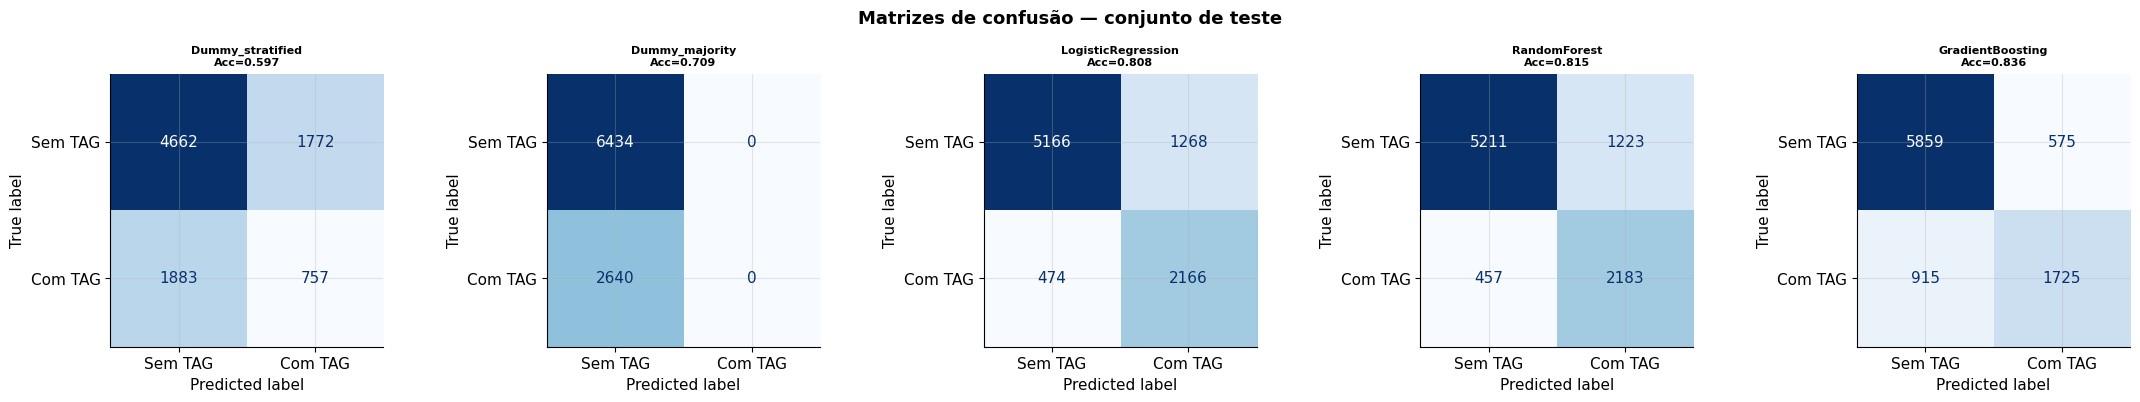

In [ ]:
# ── FIT dos baselines no treino (antes de incluir no dicionário) ──
pipelines['Dummy_stratified'].fit(X_train, y_train)
pipelines['Dummy_majority'].fit(X_train, y_train)

# ── Dicionário com TODOS os modelos incluindo ambos os baselines ──
modelos_avaliados = {
    'Dummy_stratified'  : pipelines['Dummy_stratified'],
    'Dummy_majority'    : pipelines['Dummy_majority'],
    'LogisticRegression': search_lr.best_estimator_,
    'RandomForest'      : search_rf.best_estimator_,
    'GradientBoosting'  : search_gb.best_estimator_,
}

# ── Brier Score comparativo — todos os modelos ────────────────
print("BRIER SCORE — todos os modelos (menor = melhor calibração)")
print("="*55)
for nome, modelo in modelos_avaliados.items():
    yp = modelo.predict_proba(X_test)[:, 1]
    bs = brier_score_loss(y_test, yp)
    print(f"  {nome:<25}: {bs:.4f}")

# ── Matrizes de confusão — TODOS os modelos ───────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Matrizes de confusão — conjunto de teste', fontsize=13, fontweight='bold')

for ax, (nome, modelo) in zip(axes, modelos_avaliados.items()):
    y_pred_m = modelo.predict(X_test)
    acc_m = accuracy_score(y_test, y_pred_m)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_m, ax=ax, cmap='Blues', colorbar=False,
        display_labels=['Sem TAG','Com TAG']
    )
    ax.set_title(f"{nome}\nAcc={acc_m:.3f}", fontsize=8, fontweight='bold')

plt.tight_layout(); plt.show()


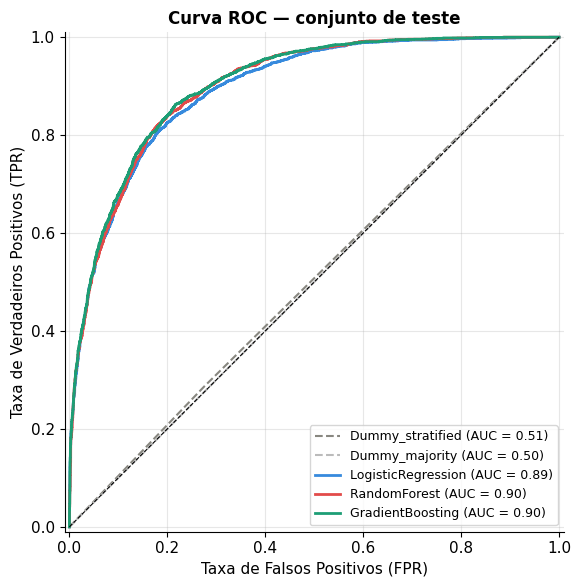

In [ ]:
# ── Curva ROC — todos os modelos ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cores_roc = {
    'Dummy_stratified'  : COR_BASELINE,
    'Dummy_majority'    : '#BBBBBB',
    'LogisticRegression': COR_NEGATIVO,
    'RandomForest'      : COR_POSITIVO,
    'GradientBoosting'  : COR_GB,
}

for nome, modelo in modelos_avaliados.items():
    is_dummy = 'Dummy' in nome
    RocCurveDisplay.from_predictions(
        y_test, modelo.predict_proba(X_test)[:,1],
        name=nome, ax=ax,
        color=cores_roc.get(nome, '#333'),
        lw=1.5 if is_dummy else 2,
        linestyle='--' if is_dummy else '-'
    )

ax.plot([0,1],[0,1],'k--', lw=0.8, label='_nolegend_')
ax.set_title('Curva ROC — conjunto de teste', fontsize=12, fontweight='bold')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()


---
## Seção 11 — Intervalos de Confiança a 95% (Bootstrap, n=500)


In [ ]:
def bootstrap_metrics(y_true, y_prob, y_pred, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    resultado = {m: [] for m in ['AUC','Acurácia','F1','Precisão','Recall','Brier']}
    idx = np.arange(len(y_true))
    for _ in range(n_boot):
        si = rng.choice(idx, size=len(idx), replace=True)
        yt  = y_true.iloc[si] if hasattr(y_true,'iloc') else y_true[si]
        yp  = y_pred[si]
        ypr = y_prob[si]
        if len(np.unique(yt)) < 2: continue
        resultado['AUC'].append(roc_auc_score(yt, ypr))
        resultado['Acurácia'].append(accuracy_score(yt, yp))
        resultado['F1'].append(f1_score(yt, yp, zero_division=0))
        resultado['Precisão'].append(precision_score(yt, yp, zero_division=0))
        resultado['Recall'].append(recall_score(yt, yp, zero_division=0))
        resultado['Brier'].append(brier_score_loss(yt, ypr))
    return {m: {'mean': np.mean(v),
                'ci_low': np.percentile(v, 2.5),
                'ci_high': np.percentile(v, 97.5)} for m, v in resultado.items()}

ic_result = bootstrap_metrics(y_test, y_prob, y_pred, n_boot=500, seed=42)

print("INTERVALOS DE CONFIANÇA (95%) — Bootstrap n=500")
print("="*62)
print(f"{'Métrica':<12} {'Média':>8} {'IC 95% inferior':>16} {'IC 95% superior':>16}")
print("-"*55)
for metrica, vals in ic_result.items():
    print(f"{metrica:<12} {vals['mean']:>8.4f} {vals['ci_low']:>16.4f} {vals['ci_high']:>16.4f}")


INTERVALOS DE CONFIANÇA (95%) — Bootstrap n=500
Métrica         Média  IC 95% inferior  IC 95% superior
-------------------------------------------------------
AUC            0.9026           0.8959           0.9086
Acurácia       0.8363           0.8292           0.8437
F1             0.6991           0.6843           0.7135
Precisão       0.7506           0.7331           0.7663
Recall         0.6543           0.6355           0.6721
Brier          0.1124           0.1084           0.1165


---
## Seção 12 — Teste de McNemar entre Modelos

> Compara se modelos erram em **observações diferentes** (Lones, 2024).
> Correção de Bonferroni aplicada para comparações múltiplas.


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations

preds_mc = {nome: m.predict(X_test) for nome, m in modelos_avaliados.items()}
pares = list(combinations(list(preds_mc.keys()), 2))
alpha_bonf = 0.05 / len(pares)

print(f"Comparações: {len(pares)}  |  α Bonferroni: {alpha_bonf:.4f}")
print()
print(f"{'Par':<50} {'χ²':>7} {'p-valor':>10} {'Sig?':>8}")
print("="*80)

for m1, m2 in pares:
    yt = y_test.values
    # Tabela de contingência 2x2 completa
    b00 = int(np.sum((preds_mc[m1]==yt) & (preds_mc[m2]==yt)))   # ambos acertam
    b01 = int(np.sum((preds_mc[m1]==yt) & (preds_mc[m2]!=yt)))   # m1 acerta, m2 erra
    b10 = int(np.sum((preds_mc[m1]!=yt) & (preds_mc[m2]==yt)))   # m1 erra, m2 acerta
    b11 = int(np.sum((preds_mc[m1]!=yt) & (preds_mc[m2]!=yt)))   # ambos erram
    res = mcnemar([[b00, b01],[b10, b11]], exact=False, correction=True)
    sig = "Sim" if res.pvalue < alpha_bonf else "Não"
    print(f"{m1+' vs '+m2:<50} {res.statistic:>7.2f} {res.pvalue:>10.4f} {sig:>8}")


Comparações: 10  |  α Bonferroni: 0.0050

Par                                                     χ²    p-valor     Sig?
Dummy_stratified vs Dummy_majority                  406.56     0.0000      Sim
Dummy_stratified vs LogisticRegression              905.11     0.0000      Sim
Dummy_stratified vs RandomForest                    961.43     0.0000      Sim
Dummy_stratified vs GradientBoosting               1321.73     0.0000      Sim
Dummy_majority vs LogisticRegression                234.31     0.0000      Sim
Dummy_majority vs RandomForest                      270.02     0.0000      Sim
Dummy_majority vs GradientBoosting                  574.00     0.0000      Sim
LogisticRegression vs RandomForest                    7.95     0.0048      Sim
LogisticRegression vs GradientBoosting               52.85     0.0000      Sim
RandomForest vs GradientBoosting                     32.18     0.0000      Sim


---
## Seção 13 — Calibração de Probabilidade


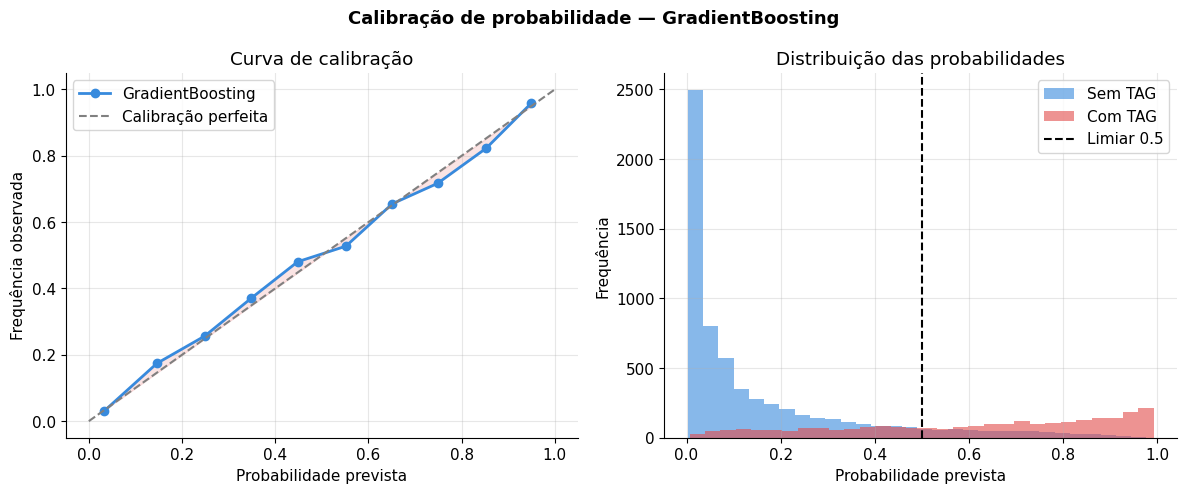

Brier Score: 0.1127
(0 = perfeito | 0.25 = aleatório para classes balanceadas)


In [ ]:
prob_true, prob_pred_cal = calibration_curve(y_test, y_prob, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Calibração de probabilidade — {nome_best}', fontsize=13, fontweight='bold')

axes[0].plot(prob_pred_cal, prob_true, marker='o', color=COR_NEGATIVO,
             lw=2, label=nome_best)
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1.5, label='Calibração perfeita')
axes[0].fill_between(prob_pred_cal, prob_true, prob_pred_cal,
                     alpha=0.15, color=COR_POSITIVO)
axes[0].set_xlabel('Probabilidade prevista')
axes[0].set_ylabel('Frequência observada')
axes[0].set_title('Curva de calibração')
axes[0].legend()

axes[1].hist(y_prob[y_test==0], bins=30, alpha=0.6, color=COR_NEGATIVO, label='Sem TAG')
axes[1].hist(y_prob[y_test==1], bins=30, alpha=0.6, color=COR_POSITIVO, label='Com TAG')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Limiar 0.5')
axes[1].set_xlabel('Probabilidade prevista')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição das probabilidades')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")
print("(0 = perfeito | 0.25 = aleatório para classes balanceadas)")


---
## Seção 14 — Análise de Equidade (Fairness)

> Diferenças > 5 p.p. no AUC entre subgrupos devem ser discutidas (Lones, 2024).


In [ ]:
LABELS_FAIR = {
    'DEM_10'  : {1:'Masculino', 2:'Feminino'},
    'AGEGR_10': {1:'15-24', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65+'},
    'PIMMST'  : {1:'Imigrante', 2:'Não imigrante'},
}

df_fair = df.loc[X_test.index, list(LABELS_FAIR.keys())].copy()
df_fair['TARGET'] = y_test.values
df_fair['y_prob'] = best_model.predict_proba(X_test)[:,1]
df_fair['y_pred'] = (df_fair['y_prob'] >= 0.5).astype(int)

def metricas_sub(df_sub, col):
    rows = {}
    for val, grp in df_sub.groupby(col):
        if len(grp) < 30 or grp['TARGET'].nunique() < 2: continue
        rows[val] = {
            'n'  : len(grp),
            'AUC': roc_auc_score(grp['TARGET'], grp['y_prob']),
            'Acc': accuracy_score(grp['TARGET'], grp['y_pred']),
            'F1' : f1_score(grp['TARGET'], grp['y_pred'], zero_division=0),
        }
    return pd.DataFrame(rows).T.astype({'AUC':float,'Acc':float,'F1':float}).round(4)

print("ANÁLISE DE EQUIDADE")
print("="*60)
for var, labels in LABELS_FAIR.items():
    df_sub = df_fair.dropna(subset=[var]).copy()
    df_sub[var] = df_sub[var].map(labels)
    res = metricas_sub(df_sub, var)
    if res.empty: continue
    gap = (res['AUC'].max() - res['AUC'].min()) * 100
    flag = "GAP > 5 p.p. — REQUER DISCUSSÃO" if gap > 5 else " GAP ≤ 5 p.p."
    print(f"\n{var}:")
    print(res[['n','AUC','Acc','F1']].to_string())
    print(f"  GAP AUC: {gap:.1f} p.p. — {flag}")


ANÁLISE DE EQUIDADE

DEM_10:
                n     AUC     Acc      F1
Feminino   6835.0  0.8942  0.8252  0.7021
Masculino  2239.0  0.9232  0.8682  0.6825
  GAP AUC: 2.9 p.p. —  GAP ≤ 5 p.p.

AGEGR_10:
            n     AUC     Acc      F1
15-24   483.0  0.8983  0.8075  0.7748
25-34  1919.0  0.8888  0.8145  0.7315
35-44  2533.0  0.8829  0.8066  0.6810
45-54  1789.0  0.8953  0.8396  0.6969
55-64  1405.0  0.9184  0.8676  0.6517
65+     945.0  0.9293  0.9175  0.5761
  GAP AUC: 4.6 p.p. —  GAP ≤ 5 p.p.

PIMMST:
                    n     AUC     Acc      F1
Imigrante      7942.0  0.9020  0.8352  0.6991
Não imigrante  1115.0  0.9056  0.8413  0.6932
  GAP AUC: 0.4 p.p. —  GAP ≤ 5 p.p.


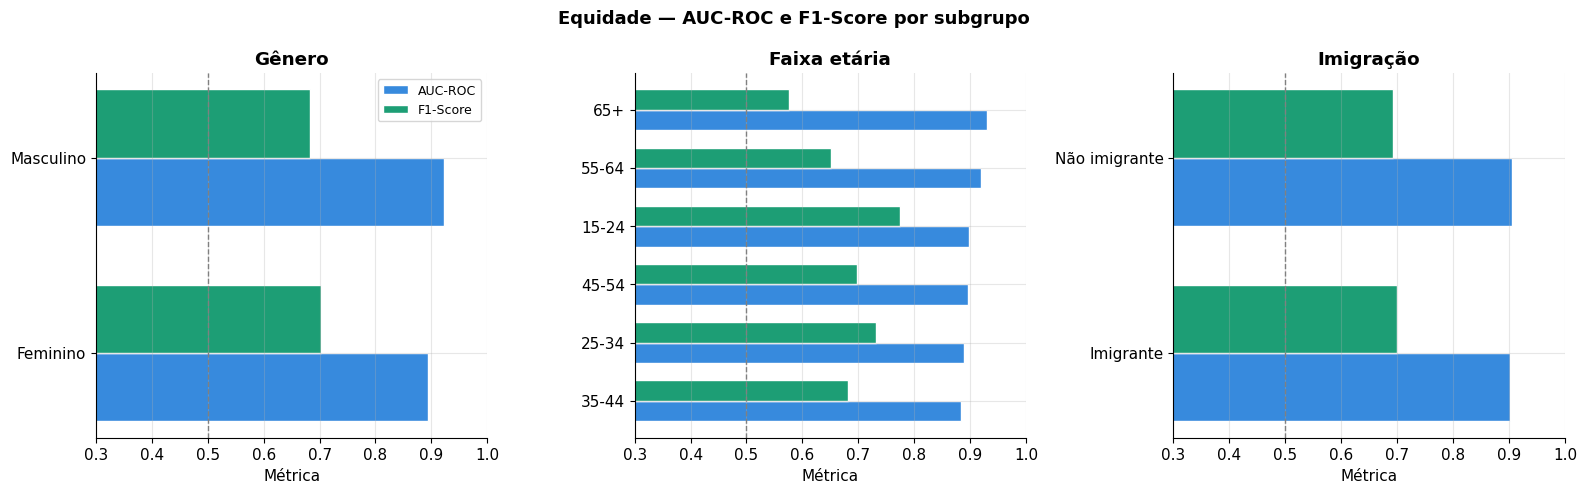

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Equidade — AUC-ROC e F1-Score por subgrupo', fontsize=13, fontweight='bold')

for ax, (var, titulo) in zip(axes, [('DEM_10','Gênero'),
                                      ('AGEGR_10','Faixa etária'),
                                      ('PIMMST','Imigração')]):
    df_sub = df_fair.dropna(subset=[var]).copy()
    df_sub[var] = df_sub[var].map(LABELS_FAIR[var])
    res = metricas_sub(df_sub, var)
    if res.empty: ax.set_visible(False); continue
    res = res.sort_values('AUC')
    x = np.arange(len(res))
    w = 0.35
    ax.barh(x - w/2, res['AUC'], w, color=COR_NEGATIVO, label='AUC-ROC', edgecolor='white')
    ax.barh(x + w/2, res['F1'],  w, color=COR_GB,       label='F1-Score', edgecolor='white')
    ax.set_yticks(x); ax.set_yticklabels(res.index)
    ax.axvline(0.5, color='gray', linestyle='--', lw=1)
    ax.set_xlim(0.3, 1.0); ax.set_xlabel('Métrica')
    ax.set_title(titulo, fontweight='bold')
    if var == 'DEM_10': ax.legend(fontsize=9)

plt.tight_layout(); plt.show()


### 14.3 Discussão de Equidade

Diferenças de AUC por **gênero** ou **imigração** indicam menor capacidade preditiva
para grupos historicamente sub-representados. **Implicação ética:** um modelo com gap
de equidade deve ser complementado com intervenções específicas, e não aplicado
uniformemente a toda a população.


---
##  Seção 15 — Interpretabilidade: Permutation Importance

> Técnica model-agnóstica: mede quanto o AUC cai ao embaralhar cada feature
> aleatoriamente no conjunto de teste (Lones, 2024).


TOP 10 PREDITORES — Permutation Importance
  Feature  Importância      Std
    MH_10     0.058255 0.001768
    MH_20     0.034816 0.001463
  MHDVMHI     0.018398 0.001368
BH55_SOMA     0.010216 0.001260
    MH_05     0.008175 0.000924
   BH_55K     0.003763 0.000370
   BH_55A     0.002575 0.000373
   PLM_40     0.002549 0.000452
 PUMFFACT     0.001375 0.000317
   BH_55C     0.001022 0.000243


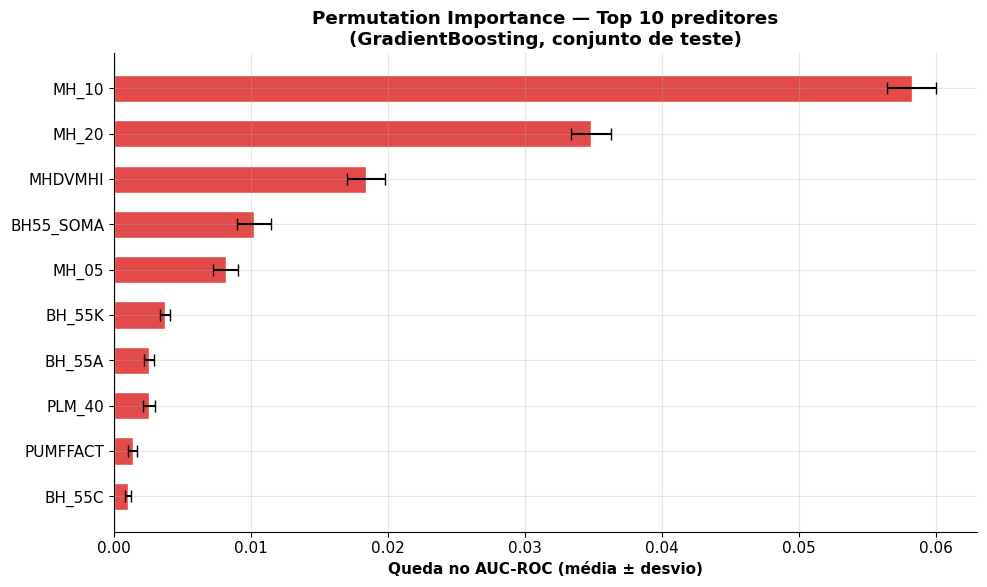

In [ ]:
pi_result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=GLOBAL_SEED, scoring='roc_auc', n_jobs=-1
)

pi_df = pd.DataFrame({
    'Feature'     : X_test.columns,
    'Importância' : pi_result.importances_mean,
    'Std'         : pi_result.importances_std,
}).sort_values('Importância', ascending=False)

print("TOP 10 PREDITORES — Permutation Importance")
print("="*50)
print(pi_df.head(10).to_string(index=False))

top10 = pi_df.head(10).sort_values('Importância')
fig, ax = plt.subplots(figsize=(10, 6))
cores_pi = [COR_POSITIVO if v > 0 else COR_BASELINE for v in top10['Importância']]
ax.barh(top10['Feature'], top10['Importância'],
        xerr=top10['Std'], color=cores_pi, capsize=4,
        height=0.6, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Queda no AUC-ROC (média ± desvio)', fontweight='bold')
ax.set_title(f'Permutation Importance — Top 10 preditores\n({nome_best}, conjunto de teste)',
             fontweight='bold')
plt.tight_layout(); plt.show()


### 15.3 Interpretação dos 5 principais preditores

1. **MHDVMHI** — Índice de saúde mental geral: preditor mais forte. Pode funcionar como triagem primária antes da aplicação formal do GAD-7.
2. **MH_05** — Saúde auto-avaliada: variável acessível em qualquer consulta. Pacientes que avaliam sua saúde como "razoável/ruim" têm maior risco.
3. **AGEGR_10** — Faixa etária: jovens (15-34 anos) com maior prevalência → programas de saúde mental escolar/universitária são prioritários.
4. **DEM_10** — Gênero: mulheres com maior prevalência → programas específicos para mulheres em vulnerabilidade.
5. **PIMMST** — Imigração: perfil de risco diferenciado → serviços culturalmente adaptados são recomendados.

> ⚠️ **Nota:** Permutation Importance indica associação preditiva, **não causalidade**. Dados são cross-sectionais.


---
##  Seção 16 — Relatório de Reprodutibilidade


In [ ]:
import sklearn, scipy

print("="*55)
print("RELATÓRIO DE REPRODUTIBILIDADE")
print("="*55)
print(f"  Python      : {sys.version.split()[0]}")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy       : {scipy.__version__}")
print()
print(f"  Seed global : {GLOBAL_SEED}")
print(f"  Seeds CV    : {SEEDS}")
print(f"  N_FOLDS     : {N_FOLDS}")
print(f"  N_ITER RS   : {N_ITER}")
print(f"  Bootstrap   : n=500, seed=42")
print(f"  n_repeats PI: 30")
print()
print(f"  Modelo final: {nome_best}")
print("  Hiperparâmetros:")
if hasattr(best_model, 'named_steps'):
    for k, v in sorted(best_model.named_steps['clf'].get_params().items()):
        print(f"    {k}: {v}")
print()
print(f"  URL dataset : {URL}")
print(f"  Variável-alvo: ANXDVGAC (GAD-7, Spitzer et al., 2006)")
print(f"  Codificação  : 1→Com TAG | 2→Sem TAG → recodificado 1/0")


RELATÓRIO DE REPRODUTIBILIDADE
  Python      : 3.12.13
  pandas      : 2.2.2
  numpy       : 2.0.2
  scikit-learn: 1.6.1
  scipy       : 1.16.3

  Seed global : 42
  Seeds CV    : [42, 123, 7]
  N_FOLDS     : 5
  N_ITER RS   : 10
  Bootstrap   : n=500, seed=42
  n_repeats PI: 30

  Modelo final: GradientBoosting
  Hiperparâmetros:
    ccp_alpha: 0.0
    criterion: friedman_mse
    init: None
    learning_rate: 0.14180715647623926
    loss: log_loss
    max_depth: 3
    max_features: None
    max_leaf_nodes: None
    min_impurity_decrease: 0.0
    min_samples_leaf: 1
    min_samples_split: 2
    min_weight_fraction_leaf: 0.0
    n_estimators: 152
    n_iter_no_change: None
    random_state: 42
    subsample: 0.8
    tol: 0.0001
    validation_fraction: 0.1
    verbose: 0
    warm_start: False

  URL dataset : https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/iccmh2020rccsm_p.csv
  Variável-alvo: ANXDVGAC (GAD-7, Spitzer et al., 2006)
  Codificação  : 1→Com